In [14]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import sklearn 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.metrics import r2_score, mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
data = pd.read_csv('Datasets/diabetes.csv')
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<Axes: ylabel='count'>

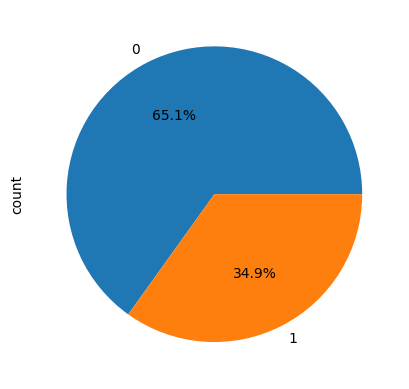

In [17]:
data['Outcome'].value_counts().plot(kind  = 'pie', autopct = '%1.1f%%')

In [12]:
lst = [x for x in data.columns if x != 'Outcome']
x = np.array(data[lst])
y = np.array(data['Outcome'])


(768,)

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3)

In [31]:
param_grid = {'ccp_alpha':np.linspace(0,0.5,100)}
grid = GridSearchCV(estimator = DecisionTreeClassifier(criterion = 'entropy'),
                    param_grid = param_grid,
                    scoring = 'accuracy',
                    cv = 5)

grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(criterion='entropy'),
             param_grid={'ccp_alpha': array([0.        , 0.00505051, 0.01010101, 0.01515152, 0.02020202,
       0.02525253, 0.03030303, 0.03535354, 0.04040404, 0.04545455,
       0.05050505, 0.05555556, 0.06060606, 0.06565657, 0.07070707,
       0.07575758, 0.08080808, 0.08585859, 0.09090909, 0.0959596 ,
       0.1010101 , 0.10606061, 0.11111111, 0.11...
       0.32828283, 0.33333333, 0.33838384, 0.34343434, 0.34848485,
       0.35353535, 0.35858586, 0.36363636, 0.36868687, 0.37373737,
       0.37878788, 0.38383838, 0.38888889, 0.39393939, 0.3989899 ,
       0.4040404 , 0.40909091, 0.41414141, 0.41919192, 0.42424242,
       0.42929293, 0.43434343, 0.43939394, 0.44444444, 0.44949495,
       0.45454545, 0.45959596, 0.46464646, 0.46969697, 0.47474747,
       0.47979798, 0.48484848, 0.48989899, 0.49494949, 0.5       ])},
             scoring='accuracy')

In [33]:
y_pred = grid.predict(x_test)
y_pred

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0])

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.86      0.80       155
           1       0.60      0.41      0.48        76

    accuracy                           0.71       231
   macro avg       0.67      0.64      0.64       231
weighted avg       0.70      0.71      0.70       231



In [37]:
importancia = pd.DataFrame({'predictor': lst,
                            'importancia': clf.feature_importances_})
importancia.sort_values('importancia', ascending = True)

,predictor,importancia
2,BloodPressure,0.047184
3,SkinThickness,0.049517
0,Pregnancies,0.064255
4,Insulin,0.087377
6,DiabetesPedigreeFunction,0.102934
7,Age,0.129768
5,BMI,0.183764
1,Glucose,0.335201


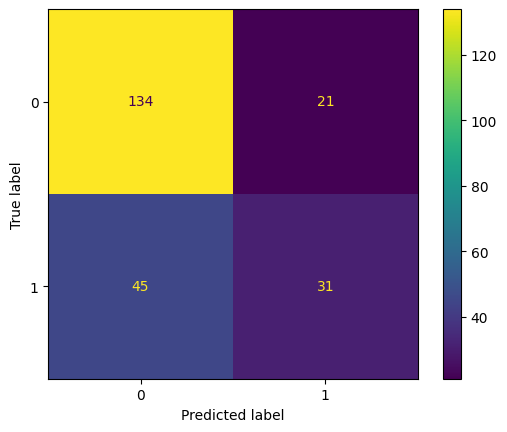

In [38]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [40]:
grid.best_estimator_

DecisionTreeClassifier(ccp_alpha=np.float64(0.015151515151515152),
                       criterion='entropy')

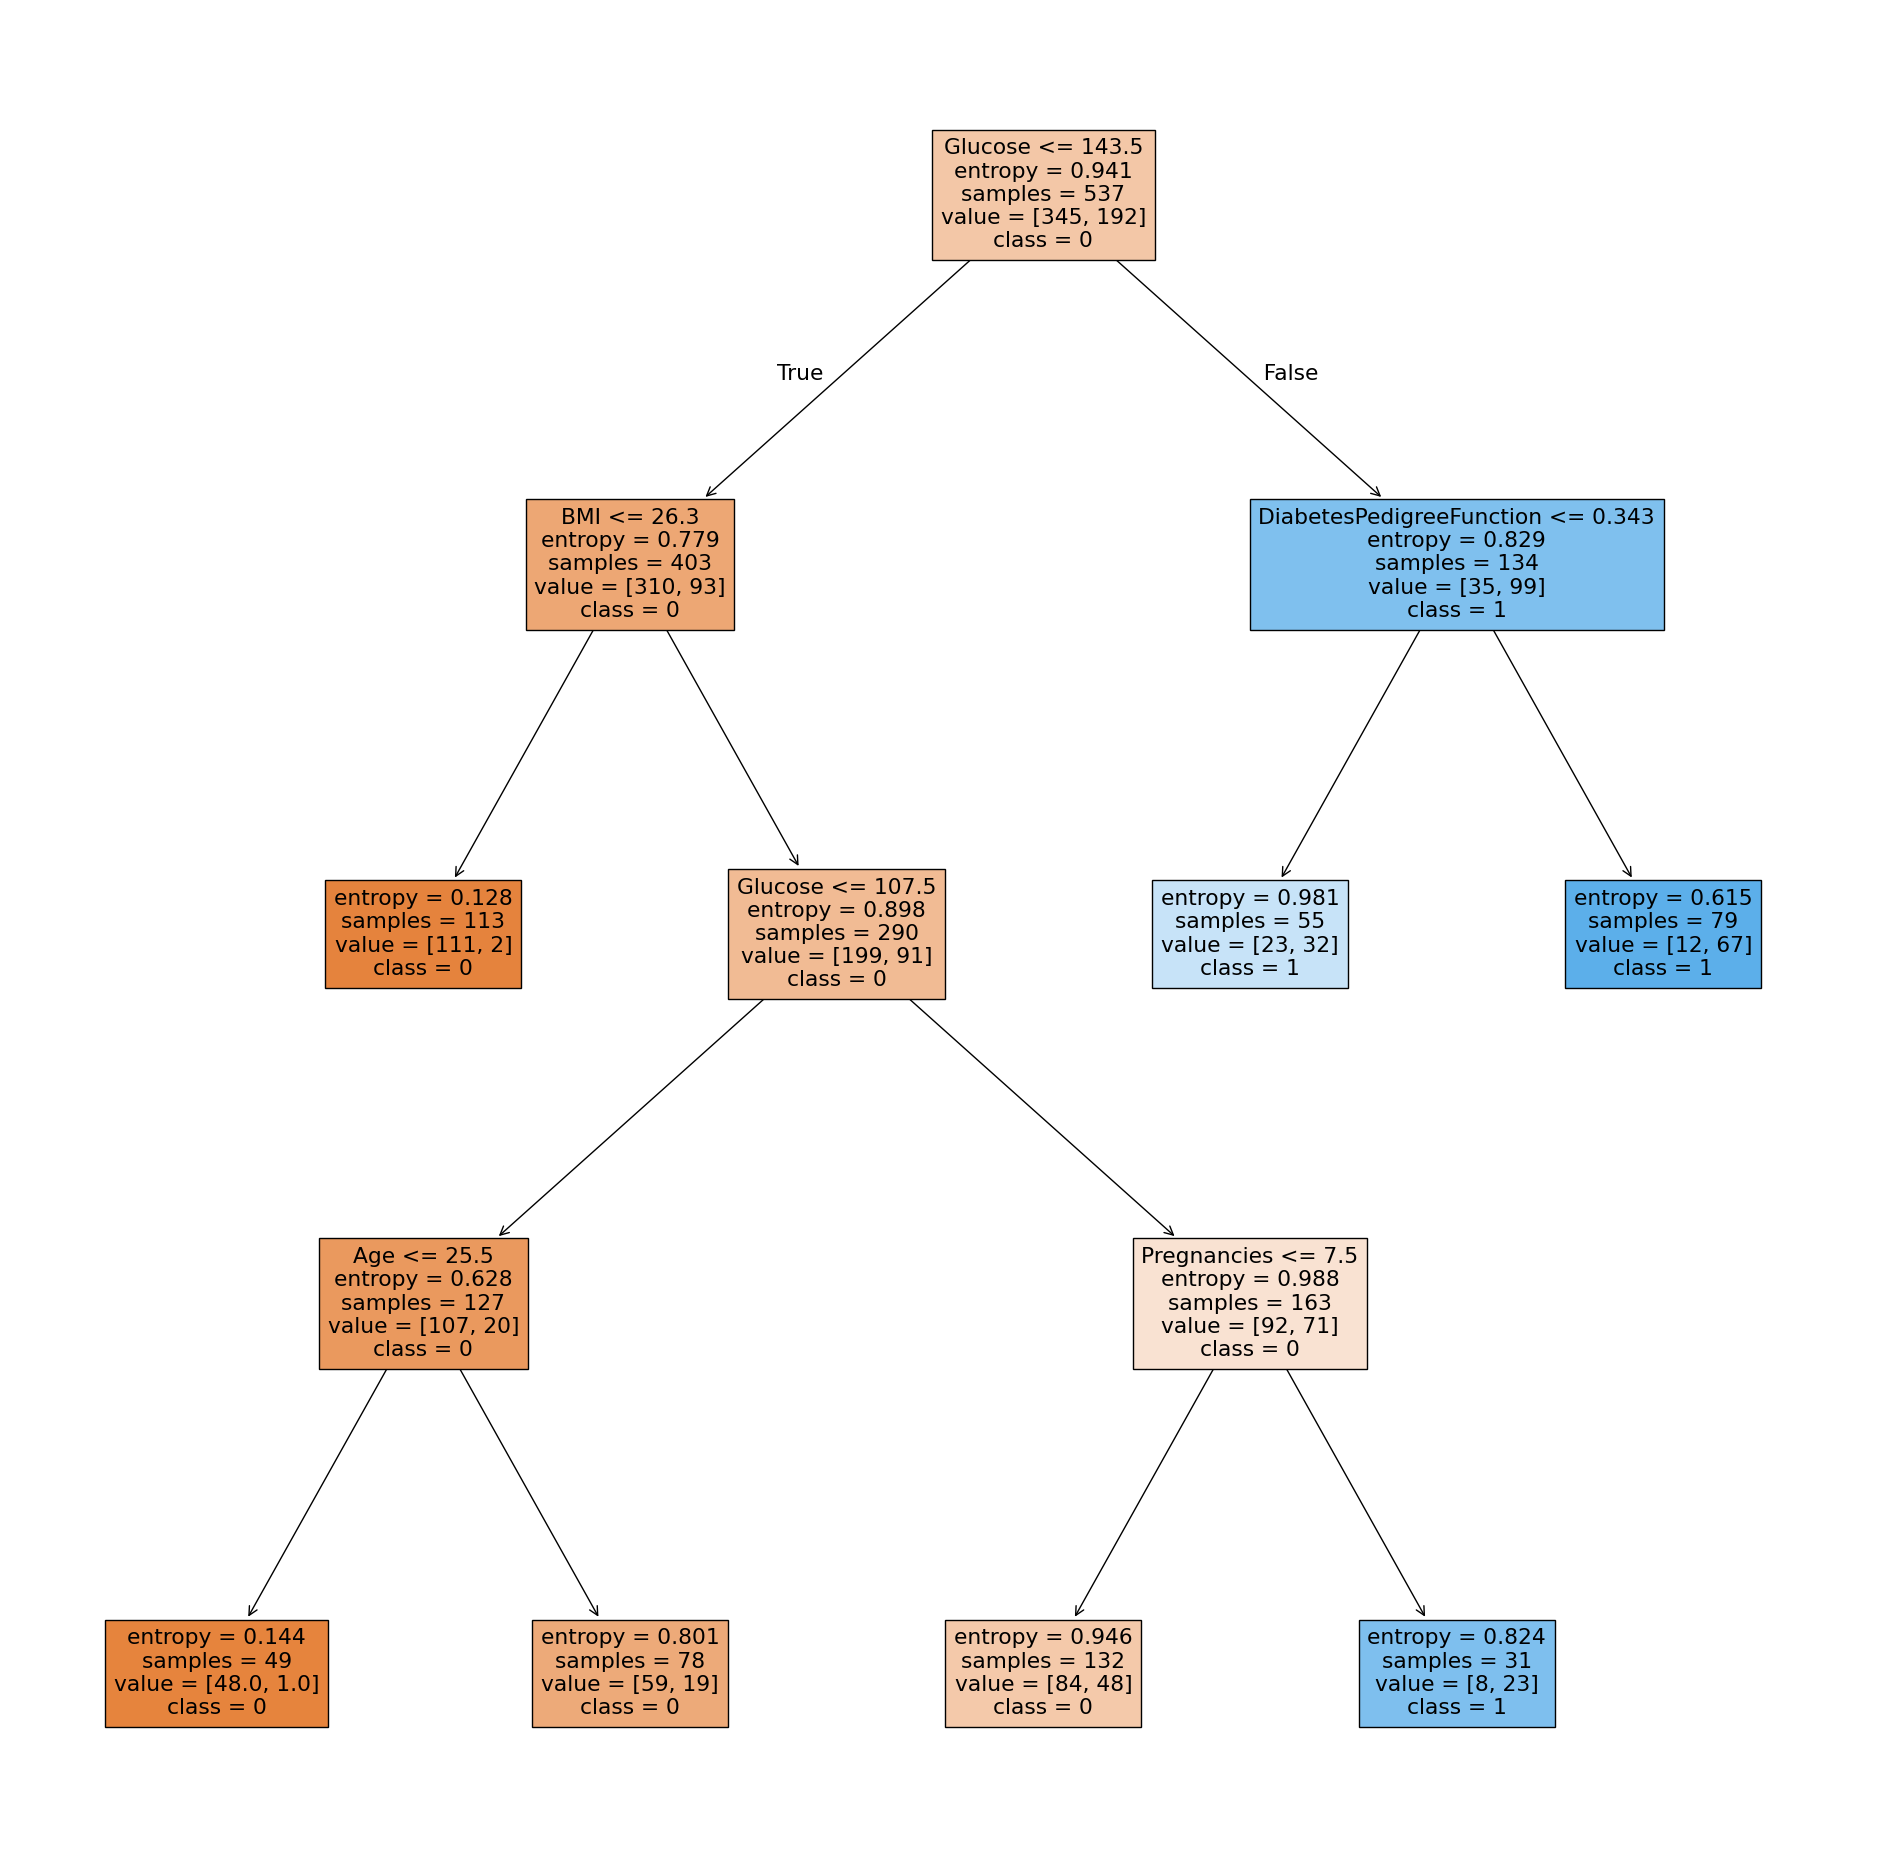

In [53]:
plt.figure(figsize =(24,24))
plot = plot_tree(decision_tree = grid.best_estimator_,
                 feature_names = lst,
                 class_names = ['0', '1'],
                 filled = True)
plt.show()